# Advanced Modeling: Random Forest

This notebook rebuilds the model using the same cleaned dataset, feature set, country grouping, and train/test split as `02_modeling.ipynb`. This keeps the Logistic Regression and Random Forest results directly comparable.


In [1]:
#Modeling Notebook - Advanced Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
)

df_curr = pd.read_csv(r"C:\Users\mklad\Desktop\Startup_Investment_App\Data\processed\processed_dataset.csv")


## Data preparation

The missing-value handling and country grouping below are intentionally the same as Notebook 2.


In [2]:
#Some of the entries have country and region as blank so first fill them with NaN and then put them into unknown category
df_curr["country_code"] = (
    df_curr["country_code"]
    .replace(r"^\s*$", np.nan, regex=True)
)

df_curr["region"] = (
    df_curr["region"]
    .replace(r"^\s*$", np.nan, regex=True)
    .fillna("Unknown")
)

df_curr["country_code"] = df_curr["country_code"].fillna("Unknown")

# Keeping the same top-five-country grouping used in 02_modeling.ipynb
top_countries = df_curr["country_code"].value_counts().head(5).index
df_curr["country_code"] = df_curr["country_code"].apply(
    lambda x: x if x in top_countries else "Other"
)

df_curr["country_code"].value_counts()


country_code
USA        27014
Other       9412
Unknown     5218
GBR         2549
CHN         1382
CAN         1328
Name: count, dtype: int64

In [3]:
# Target variable
y = df_curr["success"]

# Feature matrix - same features as the Logistic Regression notebook
X = df_curr[
    [
        "company_age",
        "Funding_log",
        "funding_rounds",
        "Industry_clean",
        "country_code"
    ]
]

# Same 80/20 stratified split for a fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])


Training rows: 37522
Test rows: 9381


## Preprocessing

Random Forest does not need scaled numeric data, but the identical `ColumnTransformer` is retained so both models receive the same inputs.


In [4]:
#Splitting features into numerical and categorical types for feeding into preprocessor
num_features = ["company_age", "Funding_log", "funding_rounds"]
cat_features = ["Industry_clean", "country_code"]

# A preprocessor is made to feed scaled and encoded data to the model
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)


## Logistic Regression baseline

This reproduces the baseline pipeline from Notebook 2 on the same split.


In [5]:
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ))
    ]
)

log_reg_pipeline.fit(X_train, y_train)

y_pred_log = log_reg_pipeline.predict(X_test)
y_prob_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression classification report")
print(classification_report(y_test, y_pred_log))


Logistic Regression classification report
              precision    recall  f1-score   support

           0       0.19      0.61      0.29      1219
           1       0.91      0.61      0.73      8162

    accuracy                           0.61      9381
   macro avg       0.55      0.61      0.51      9381
weighted avg       0.82      0.61      0.68      9381



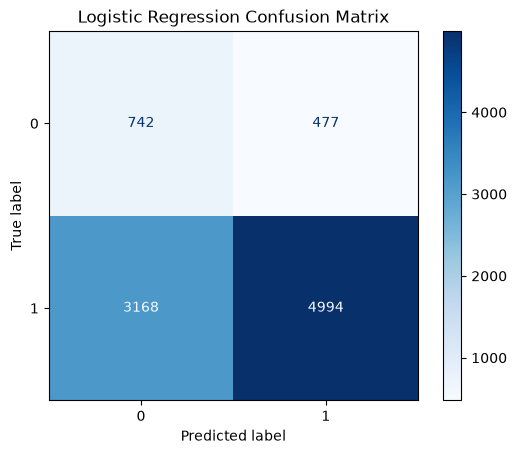

In [6]:
# Confusion matrix for the Logistic Regression baseline
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Random Forest with light tuning

`RandomizedSearchCV` tries a small selection of tree counts, depths, and split sizes. F1 is used for selection because the target classes are imbalanced.


In [7]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Light hyperparameter search
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20]
}

random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best cross-validation F1 score:", round(random_search.best_score_, 3))
print("Best parameters:", random_search.best_params_)


Best cross-validation F1 score: 0.9
Best parameters: {'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__max_depth': 5}


## Random Forest evaluation


Random Forest classification report
              precision    recall  f1-score   support

           0       0.33      0.41      0.37      1219
           1       0.91      0.88      0.89      8162

    accuracy                           0.82      9381
   macro avg       0.62      0.64      0.63      9381
weighted avg       0.83      0.82      0.82      9381



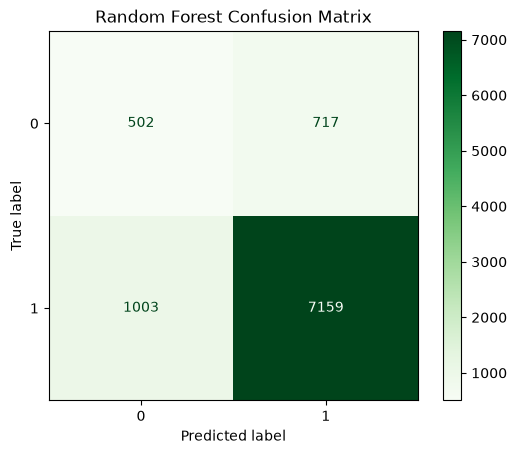

In [8]:
best_rf_pipeline = random_search.best_estimator_

y_pred_rf = best_rf_pipeline.predict(X_test)
y_prob_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest classification report")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()


## ROC-AUC comparison

ROC-AUC compares how well each model ranks successful startups above unsuccessful ones across all probability thresholds.


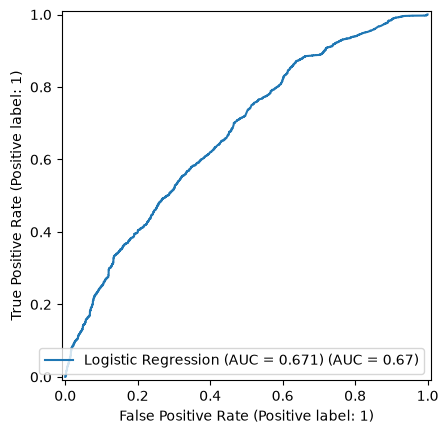

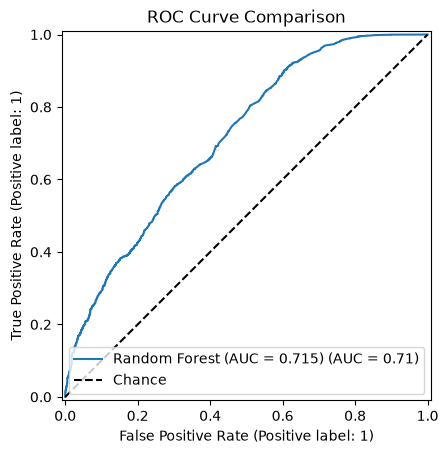

In [9]:
log_auc = roc_auc_score(y_test, y_prob_log)
rf_auc = roc_auc_score(y_test, y_prob_rf)

RocCurveDisplay.from_predictions(y_test, y_prob_log, name=f"Logistic Regression (AUC = {log_auc:.3f})")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## Feature importances

Random Forest feature importance shows which transformed input features were used most in the model's tree splits.


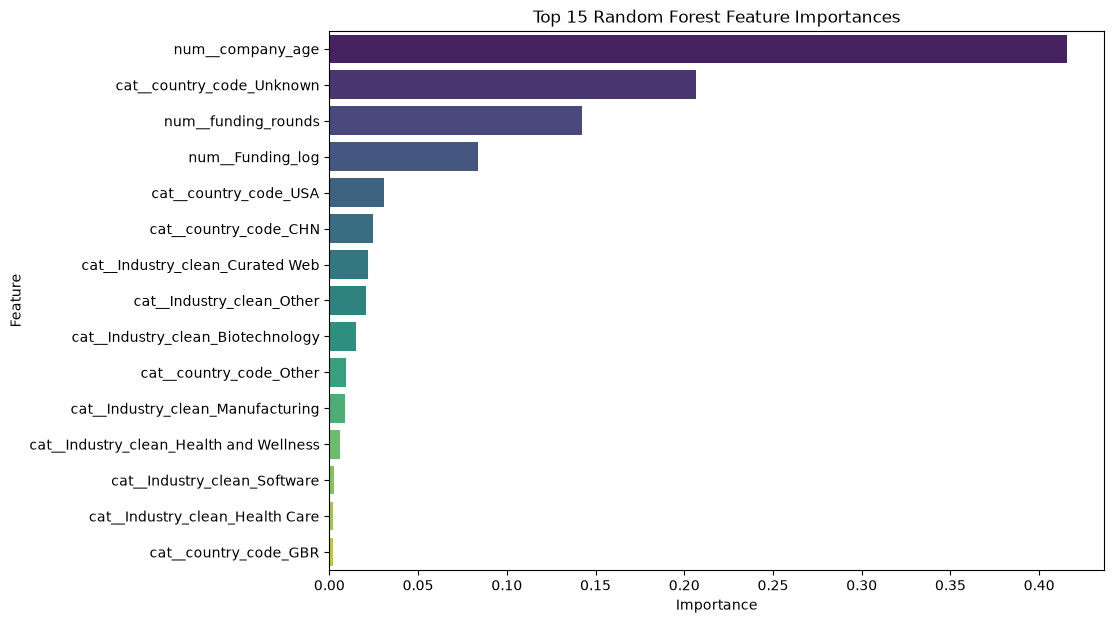

,feature,importance
0,num__company_age,0.415933
23,cat__country_code_Unknown,0.206534
2,num__funding_rounds,0.142472
1,num__Funding_log,0.084001
22,cat__country_code_USA,0.030572
19,cat__country_code_CHN,0.024370
6,cat__Industry_clean_Curated Web,0.021835
15,cat__Industry_clean_Other,0.020914
4,cat__Industry_clean_Biotechnology,0.015074
21,cat__country_code_Other,0.009267


In [10]:
# Getting feature names after scaling and one-hot encoding
feature_names = best_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_importances = best_rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(15), x="importance", y="feature", hue="feature", legend=False, palette="viridis")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importance_df.head(15)


## Model comparison and takeaway


In [11]:
# Building one table so both models can be compared on the same test set
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, y_pred_log, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    "AUC": [log_auc, rf_auc]
})

summary = summary.round(3)
summary


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.611,0.913,0.612,0.733,0.671
1,Random Forest,0.817,0.909,0.877,0.893,0.715


In [12]:
# Choosing the final model by F1 first, then AUC if F1 is tied
best_model = summary.sort_values(["F1", "AUC"], ascending=False).iloc[0]

print(
    f"Takeaway: Use {best_model['Model']} as the final model for this dataset. "
    f"It has the stronger test-set F1 score ({best_model['F1']:.3f}) and "
    f"an AUC of {best_model['AUC']:.3f}. "
    "Keep Logistic Regression as the simpler and more interpretable baseline."
)


Takeaway: Use Random Forest as the final model for this dataset. It has the stronger test-set F1 score (0.893) and an AUC of 0.715. Keep Logistic Regression as the simpler and more interpretable baseline.
